# PJM DART Spread — DOM Zone

EDA and results notebook. Pipeline logic (feature engineering, baselines, models, backtest) lives in `scripts/` and is imported here rather than reimplemented inline — see `MODEL.md` and `SPEC.md` for the design and decisions behind it.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd

from scripts.data_collection import INPUT_DATA_DIR

df = pd.read_csv(INPUT_DATA_DIR / "dart_data.csv", index_col="interval_start_utc", parse_dates=True)
df.head()

,da_lmp,rt_lmp,da_energy,rt_energy,da_congestion,rt_congestion,da_loss,rt_loss,dart,load_forecast
interval_start_utc,,,,,,,,,,
2019-01-01 00:00:00+00:00,24.550394,19.863592,24.27,19.66,0.000000,-0.083244,0.280394,0.288503,4.686802,12126.0
2019-01-01 01:00:00+00:00,23.514936,19.357343,23.14,19.10,0.080000,0.002759,0.294936,0.259584,4.157593,11748.0
2019-01-01 02:00:00+00:00,22.592422,18.809284,22.27,18.63,0.060069,0.000357,0.262353,0.180593,3.783138,11122.0
2019-01-01 03:00:00+00:00,20.814471,18.482355,20.55,18.33,0.050000,0.000793,0.214471,0.149063,2.332116,10321.0
2019-01-01 04:00:00+00:00,19.800852,18.052672,19.57,17.96,0.044227,0.000000,0.186625,0.093505,1.748180,9546.0


## Shape, dtypes, coverage, missingness

In [2]:
print(f"rows: {len(df):,}   cols: {df.shape[1]}")
print(f"date range: {df.index.min()}  ->  {df.index.max()}")
print()
df.info()
print()
print("missing values per column:")
print(df.isna().sum())

rows: 61,368   cols: 10
date range: 2019-01-01 00:00:00+00:00  ->  2025-12-31 23:00:00+00:00

<class 'pandas.DataFrame'>
DatetimeIndex: 61368 entries, 2019-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   da_lmp         61368 non-null  float64
 1   rt_lmp         61368 non-null  float64
 2   da_energy      61368 non-null  float64
 3   rt_energy      61368 non-null  float64
 4   da_congestion  61368 non-null  float64
 5   rt_congestion  61368 non-null  float64
 6   da_loss        61368 non-null  float64
 7   rt_loss        61368 non-null  float64
 8   dart           61368 non-null  float64
 9   load_forecast  61079 non-null  float64
dtypes: float64(10)
memory usage: 5.2 MB

missing values per column:
da_lmp             0
rt_lmp             0
da_energy          0
rt_energy          0
da_congestion      0
rt_congestion      0
da_loss            0
rt_loss          

## Gaps in the hourly index

The index should be one row per hour with no duplicates. Check both, since gaps or dupes (e.g. around DST transitions) would silently bias any time-based feature or backtest.

In [3]:
full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
missing_hours = full_range.difference(df.index)
dupe_hours = df.index[df.index.duplicated()]

print(f"expected hourly rows: {len(full_range):,}")
print(f"missing hours: {len(missing_hours)}")
print(f"duplicate index timestamps: {len(dupe_hours)}")
if len(missing_hours):
    print(missing_hours[:10])
if len(dupe_hours):
    print(dupe_hours[:10])

expected hourly rows: 61,368
missing hours: 0
duplicate index timestamps: 0


## Descriptive statistics

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
da_lmp,61368.0,43.906463,37.447925,6.640822,23.243287,32.527629,50.729388,678.089345
rt_lmp,61368.0,44.846204,70.189908,-53.570167,21.246317,29.562428,47.945505,4392.119704
da_energy,61368.0,37.575069,27.234747,6.190000,21.717500,29.500000,44.010000,537.130000
rt_energy,61368.0,37.951398,53.345205,-52.770000,20.220000,27.660000,43.022500,3700.000000
da_congestion,61368.0,5.588496,13.847119,-15.233061,0.570033,1.963981,5.133574,348.802406
rt_congestion,61368.0,6.201928,25.456234,-198.758623,0.000000,0.679295,3.579804,663.582988
da_loss,61368.0,0.742899,1.028116,-4.976691,0.138917,0.484377,1.055924,18.994735
rt_loss,61368.0,0.693299,2.164066,-10.362411,0.145825,0.427165,0.883249,275.580569
dart,61368.0,-0.939741,56.876981,-3977.226617,-1.142509,2.174681,7.039661,411.914786
load_forecast,61079.0,13060.806546,2735.372598,6793.000000,11074.000000,12687.000000,14647.500000,25028.000000


## Distribution of DART

`dart = da_lmp - rt_lmp`. Positive favors INC offers, negative favors DEC bids. Energy price spreads are typically heavy-tailed (RT prices spike during scarcity events), so check skew/kurtosis and look at the tails directly rather than assuming near-normality.

mean:     -0.940
median:   2.175
std:      56.877
skew:     -31.318
kurtosis: 1642.556
share > 0 (INC favorable): 68.0%
share < 0 (DEC favorable): 32.0%


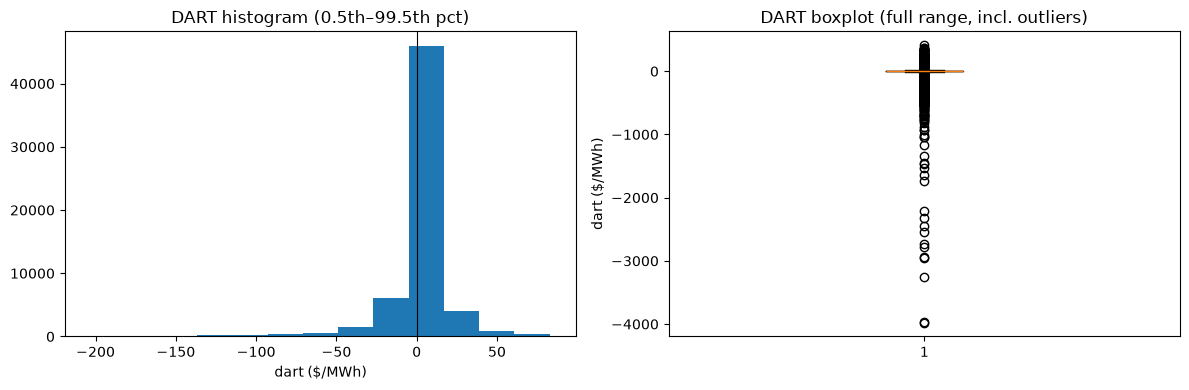

In [5]:
import matplotlib.pyplot as plt

print(f"mean:     {df['dart'].mean():.3f}")
print(f"median:   {df['dart'].median():.3f}")
print(f"std:      {df['dart'].std():.3f}")
print(f"skew:     {df['dart'].skew():.3f}")
print(f"kurtosis: {df['dart'].kurtosis():.3f}")
print(f"share > 0 (INC favorable): {(df['dart'] > 0).mean():.1%}")
print(f"share < 0 (DEC favorable): {(df['dart'] < 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["dart"], bins=200)
axes[0].set_xlim(df["dart"].quantile(0.005), df["dart"].quantile(0.995))
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("DART histogram (0.5th–99.5th pct)")
axes[0].set_xlabel("dart ($/MWh)")

axes[1].boxplot(df["dart"], showfliers=True)
axes[1].set_title("DART boxplot (full range, incl. outliers)")
axes[1].set_ylabel("dart ($/MWh)")

plt.tight_layout()
plt.show()

### Most extreme DART hours

The largest spreads are where virtual trading PnL — and forecast error — would concentrate. The most negative values below cluster on Dec 23–24, 2022: PJM's emergency load-shed event during Winter Storm Elliott, when RT prices spiked to their system cap while DA prices (set the day before) had no way to see it coming — a textbook example of why DART has fat tails and why any leak-free feature set will still miss ex-ante-unforecastable events like this one.

In [6]:
cols = ["da_lmp", "rt_lmp", "dart", "load_forecast"]
print("largest positive DART (INC-favorable):")
display(df.nlargest(5, "dart")[cols])

print("\nlargest negative DART (DEC-favorable):")
display(df.nsmallest(5, "dart")[cols])

largest positive DART (INC-favorable):


,da_lmp,rt_lmp,dart,load_forecast
interval_start_utc,,,,
2025-07-29 21:00:00+00:00,664.904059,252.989273,411.914786,23868.0
2025-05-16 21:00:00+00:00,430.999997,60.453225,370.546772,20345.0
2025-07-29 22:00:00+00:00,678.089345,316.247018,361.842327,23738.0
2022-12-25 22:00:00+00:00,482.571217,124.964526,357.606691,19637.0
2025-05-16 22:00:00+00:00,388.880158,36.048905,352.831253,20027.0



largest negative DART (DEC-favorable):


,da_lmp,rt_lmp,dart,load_forecast
interval_start_utc,,,,
2022-12-23 22:00:00+00:00,259.568771,4236.795388,-3977.226617,18560.0
2022-12-24 09:00:00+00:00,430.580823,4392.119704,-3961.538881,18291.0
2022-12-24 08:00:00+00:00,430.377101,3687.816103,-3257.439002,18117.0
2022-12-24 07:00:00+00:00,376.197845,3326.912806,-2950.714961,18109.0
2022-12-24 10:00:00+00:00,449.450168,3387.359280,-2937.909112,18629.0


## Time series view

DA/RT LMP and DART over the full history. Resampled to daily mean — plotting all ~61k hourly points directly is unreadable and the hour-to-hour noise isn't the point at this zoom level.

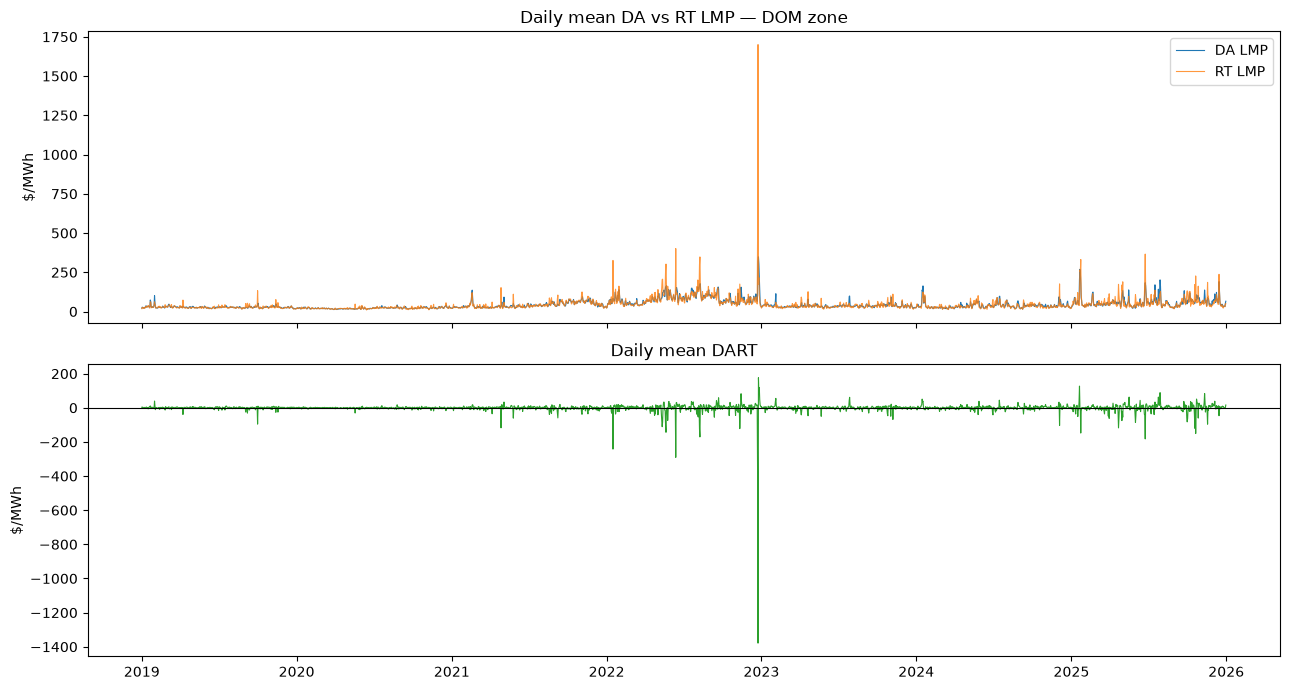

In [7]:
daily = df.resample("D").mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(daily.index, daily["da_lmp"], label="DA LMP", linewidth=0.8)
axes[0].plot(daily.index, daily["rt_lmp"], label="RT LMP", linewidth=0.8, alpha=0.8)
axes[0].set_ylabel("$/MWh")
axes[0].set_title("Daily mean DA vs RT LMP — DOM zone")
axes[0].legend()

axes[1].plot(daily.index, daily["dart"], color="tab:green", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("$/MWh")
axes[1].set_title("Daily mean DART")

plt.tight_layout()
plt.show()

## Seasonality of DART

MODEL.md's feature set includes hour-of-day, day-of-week, and month specifically because DART is expected to have calendar structure (e.g. RT price spikes concentrated in high-load hours). Check whether that structure actually shows up before trusting those features.

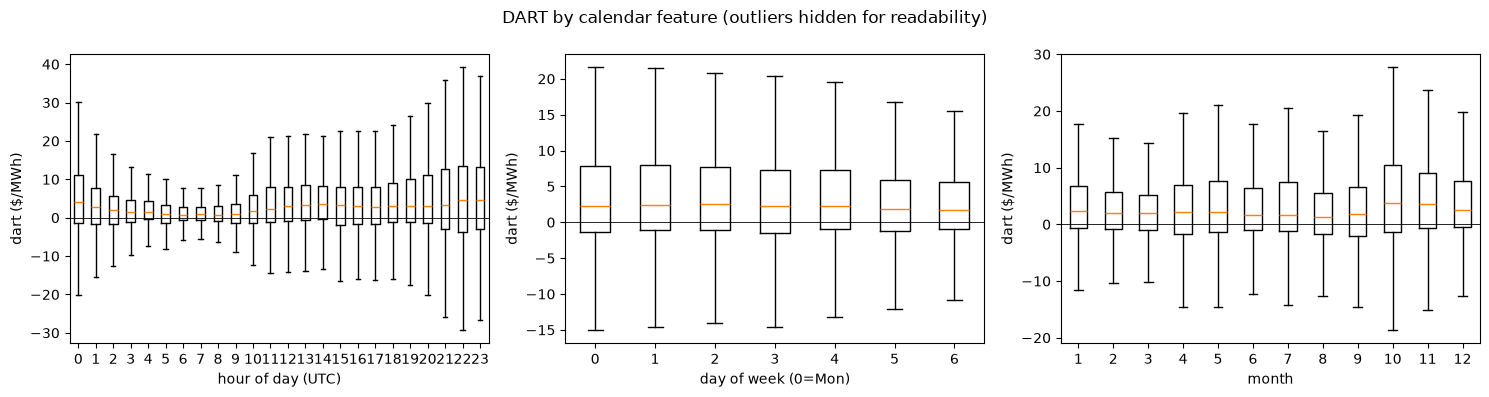

In [8]:
cal = df.copy()
cal["hour_of_day"] = cal.index.hour
cal["day_of_week"] = cal.index.dayofweek  # 0=Mon
cal["month"] = cal.index.month

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, xlabel in [
    (axes[0], "hour_of_day", "hour of day (UTC)"),
    (axes[1], "day_of_week", "day of week (0=Mon)"),
    (axes[2], "month", "month"),
]:
    groups = [cal.loc[cal[col] == v, "dart"] for v in sorted(cal[col].unique())]
    ax.boxplot(groups, showfliers=False, tick_labels=sorted(cal[col].unique()))
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("dart ($/MWh)")

plt.suptitle("DART by calendar feature (outliers hidden for readability)")
plt.tight_layout()
plt.show()

## DART vs. load forecast

`load_forecast` is the only non-price, leak-free feature currently in the pipeline (per MODEL.md). Check whether it has any visible relationship with DART on its own, before feature engineering.

corr(load_forecast, dart) = -0.017
corr(load_forecast, |dart|) = 0.209


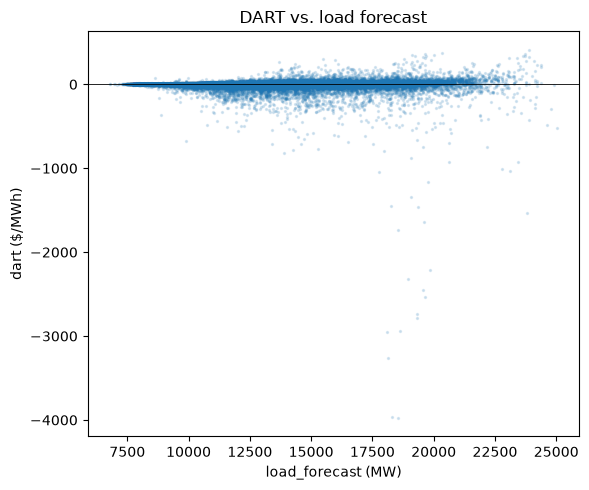

In [9]:
corr = df["load_forecast"].corr(df["dart"])
print(f"corr(load_forecast, dart) = {corr:.3f}")
print(f"corr(load_forecast, |dart|) = {df['load_forecast'].corr(df['dart'].abs()):.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["load_forecast"], df["dart"], s=2, alpha=0.15)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xlabel("load_forecast (MW)")
ax.set_ylabel("dart ($/MWh)")
ax.set_title("DART vs. load forecast")
plt.tight_layout()
plt.show()

## Correlation matrix

Includes the DA/RT price components (`*_energy`, `*_congestion`, `*_loss`) alongside `dart` and `load_forecast`, to see which components DART's variance actually traces back to.

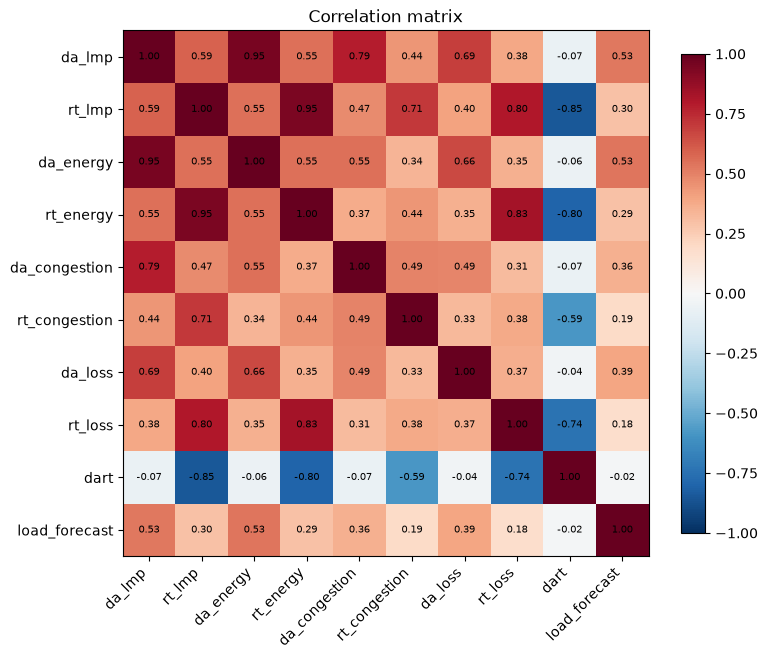

In [10]:
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## Year-over-year trend

README's premise is that DOM-zone congestion has grown with Northern Virginia data-center load. Check whether DART's level and volatility actually trend up across years, or whether that story hasn't shown up in the price data (yet).

In [11]:
yearly = df.groupby(df.index.year).agg(
    dart_mean=("dart", "mean"),
    dart_std=("dart", "std"),
    dart_abs_mean=("dart", lambda s: s.abs().mean()),
    load_forecast_mean=("load_forecast", "mean"),
    n_hours=("dart", "size"),
)
yearly

,dart_mean,dart_std,dart_abs_mean,load_forecast_mean,n_hours
interval_start_utc,,,,,
2019,0.241135,23.952284,5.947364,11694.913919,8760
2020,-0.192602,12.067727,4.880243,11460.408219,8784
2021,-1.132159,29.147020,10.957372,12362.989125,8760
2022,-5.812382,125.775588,29.549016,13063.892332,8760
2023,0.050301,27.267775,11.267169,13274.615491,8760
2024,0.877188,28.263161,12.426717,14154.093434,8784
2025,-0.616689,60.839410,25.072981,15417.454338,8760


## Summary

- **Coverage**: hourly with no gaps or duplicate timestamps across 2019–2025 (61,368 rows). All price columns and `dart` are fully populated; `load_forecast` is missing for 289 hours (~0.5%), scattered in short multi-hour blocks across most years rather than concentrated at the start of history — worth a real missing-data policy before training, per MODEL.md's "Not Yet Decided" section.
- **DART is heavy-tailed and only mildly directional**: mean ≈ -0.9, median ≈ +2.2, but skew ≈ -31 and kurtosis ≈ 1,600 — almost entirely driven by a handful of extreme negative hours during Winter Storm Elliott (Dec 2022, DART to -3,977 $/MWh), not a general property of every day. 68% of hours favor INC, 32% favor DEC. This is why MODEL.md scores with MAE/RMSE on the raw (unclipped) target rather than assuming near-Gaussian errors.
- **Calendar structure is real**: DART varies visibly by hour-of-day (and to a lesser extent day-of-week/month), supporting MODEL.md's choice to include `hour_of_day`, `day_of_week`, and `month` as one-hot features.
- **`load_forecast` has almost no linear relationship with signed `dart`** (corr ≈ -0.02) but a moderate relationship with **|dart|** (corr ≈ 0.21) — it says more about when spreads get volatile than about which direction they'll go, which matters for how much predictive value to expect from it alone.
- **Year-over-year, 2022 is the outlier** (dart_std ≈ 126 vs. 12–29 in other years) entirely due to Elliott; 2025 is also elevated (std ≈ 61) alongside the highest average `load_forecast` of any year — tentatively consistent with the README's data-center load growth story, but one year of coincidence isn't a trend and this is worth revisiting once weather or DC-specific load features are added (README's v2 roadmap).